# Team 04 — Site Grid & Side Alignment (Phase 3)

Real buildings are **not** dropped at arbitrary rotations inside a plot. They sit on a **straight site
grid**, with lines **parallel and perpendicular to one chosen side** (the street frontage / the
longest edge / the side chosen by sun analysis). This notebook places buildings **rigidly aligned**
to that grid, on a **complex non-orthogonal site**.

What this adds over free placement:

1. A **straight site grid** derived from a *chosen side* — buildings can only take the {parallel,
   perpendicular} orientations of that side (`site_grid.derive_site_grid` / `aligned_orientations`).
2. **It no longer looks random** — free vs. grid-aligned, side by side, for identical fitness.
3. **Placement by function**: the building's **use** decides its orientation — commercial/retail
   front the side (long side **parallel**); residential/office go deep (long side **perpendicular**).
   The agent asks the user the function (`orientation_for_function` / `place_building_by_function`).
4. **Use-driven optimization**: a **commercial** building hugs the chosen frontage
   (`boundary_proximity`), while residential leans on view + sun.
5. Two or more buildings placed **together**, each aligned and clearing the rest.

Deterministic (no LLM); only matplotlib is needed.

In [1]:
from __future__ import annotations
import sys, math
from pathlib import Path

workspace_root = Path.cwd().resolve()
candidate_roots = (workspace_root, workspace_root.parent,
                   workspace_root / 'team_04', workspace_root.parent / 'team_04')
TEAM_ROOT = next((p for p in candidate_roots if (p / 'agent').exists()), None)
if TEAM_ROOT is None:
    raise FileNotFoundError('Run from workspace root, team_04, or team_04/test_notebooks.')
if str(TEAM_ROOT) not in sys.path:
    sys.path.insert(0, str(TEAM_ROOT))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from agent.tools.site_model import build_site_model
from agent.tools.building_shape_graph import build_shape_model
from agent.tools.parametric_shape import apply_shape_variables, shape_variable_spec
from agent.tools.site_grid import (
    derive_site_grid, aligned_orientations, align_building_to_grid, alignment_score,
    snap_to_grid, corner_interior_angle, corner_wing_rotation,
)
from agent.tools.view_optimizer import (
    sample_valid_placements, optimize_aligned_placement, place_buildings_aligned,
)
print('Team root:', TEAM_ROOT)

Team root: C:\Users\tuemi\Downloads\Glabtools\IAAC Repo\bimsc26-datamgmt-session03\AIA26_Studio\team_04


## 1. Complex site + the derived grid

A splayed, non-orthogonal pentagon (no right angles). The grid is derived from the **longest side**
by default (the sensible fallback before roads land in Phase 2) — origin + two axes, clipped to the
buildable zone, drawn as grid lines with seed nodes.

chosen side   : 0 side_0
grid angle    : 7.8831 deg
orientations  : [7.8831, 97.8831] (parallel, perpendicular)
grid nodes    : 76


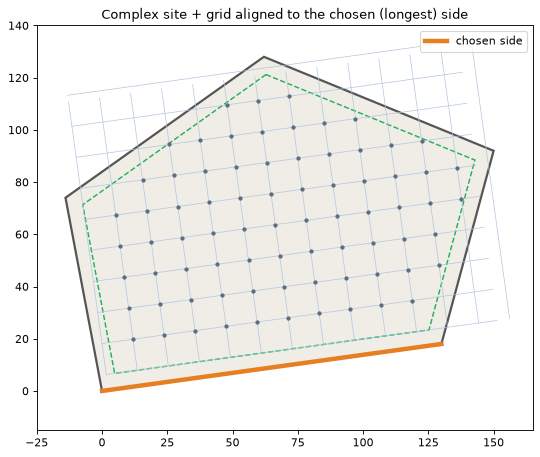

In [2]:
SITE = [[0, 0, 0], [130, 18, 0], [150, 92, 0], [62, 128, 0], [-14, 74, 0], [0, 0, 0]]
site_model = build_site_model(SITE, {'default_setback': 6.0})
grid = derive_site_grid(site_model, spacing=12.0)   # default: longest side

print('chosen side   :', grid['alignment_side_index'], grid['alignment_side_label'])
print('grid angle    :', grid['angle_deg'], 'deg')
print('orientations  :', aligned_orientations(grid), '(parallel, perpendicular)')
print('grid nodes    :', grid['node_count'])

def draw_site(ax, model=site_model, site=SITE):
    ax.add_patch(plt.Polygon([(p[0], p[1]) for p in site[:-1]], fc='#f0ede6', ec='#555', lw=2, zorder=1))
    bz = (model.get('setbacks') or {}).get('buildable_boundary')
    if bz:
        ax.add_patch(plt.Polygon([(p[0], p[1]) for p in bz[:-1]], fc='none', ec='#27ae60', lw=1.3, ls='--', zorder=2))
    ax.set_aspect('equal')

def draw_grid(ax, g, nodes=True):
    for ln in g['grid_lines']:
        ax.plot([ln[0][0], ln[1][0]], [ln[0][1], ln[1][1]], color='#b0c4de', lw=0.6, zorder=2)
    if nodes:
        xs = [n[0] for n in g['grid_nodes']]; ys = [n[1] for n in g['grid_nodes']]
        ax.scatter(xs, ys, s=8, color='#5d6d7e', zorder=3)
    # highlight the chosen side
    i = g['alignment_side_index']; coords = [(p[0], p[1]) for p in SITE[:-1]]
    a = coords[i]; b = coords[(i + 1) % len(coords)]
    ax.plot([a[0], b[0]], [a[1], b[1]], color='#e67e22', lw=4, zorder=4, label='chosen side')

fig, ax = plt.subplots(figsize=(8, 7))
draw_site(ax); draw_grid(ax, grid)
ax.legend(loc='upper right'); ax.set_title('Complex site + grid aligned to the chosen (longest) side')
ax.set_xlim(-25, 165); ax.set_ylim(-15, 140)
plt.show()

## 1b. Place by function — straight grid, parallel & perpendicular

We pick a side (here the longest; in practice the side **chosen by sun analysis**) and draw a
**straight grid** whose lines are exactly **parallel and perpendicular** to it — no warping. A
building is placed **rigidly** on that grid: its edges are parallel/perpendicular to the chosen side,
never at a random angle.

The building's **function** decides which way its *length* faces the side (`orientation_for_function`):

- **commercial / retail** → long side **parallel** to the chosen side (maximise street frontage)
- **residential / office** → long side **perpendicular** (deeper plan, better light + privacy)

The agent asks the user the building's function and passes it as `function=`. Below, the same U is
placed both ways — `edges 0° off-grid` confirms it sits perfectly square to the chosen side.

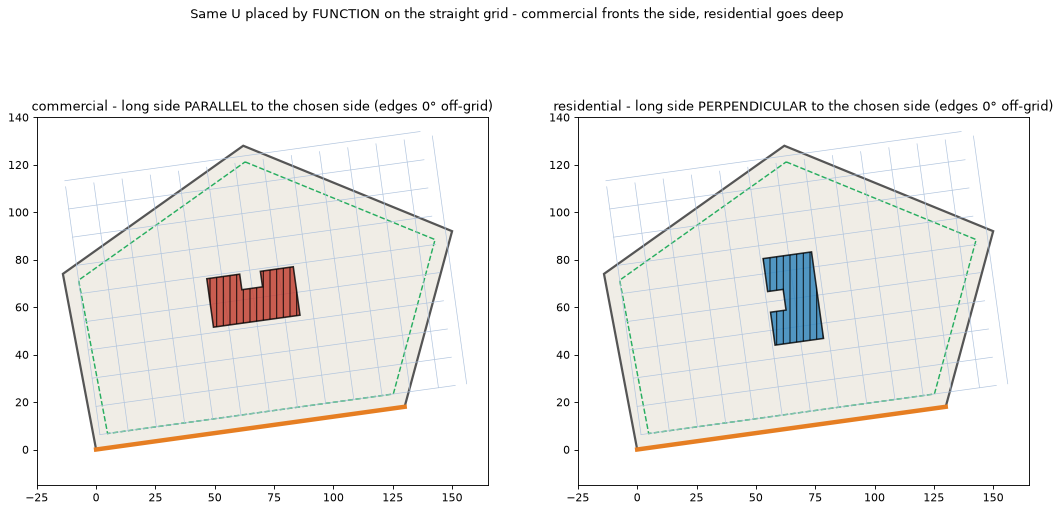

In [3]:
from agent.tools.site_grid import (
    orientation_for_function, place_building_by_function, frontage_for_function,
)
from agent.tools.view_analysis import _coerce_polygon_2d

# The grid from section 1 is STRAIGHT — lines exactly parallel + perpendicular to the
# chosen side. A building is placed RIGIDLY on it (edges parallel/perpendicular to the
# side, never a random angle). Its FUNCTION decides the orientation:
#   commercial / retail -> long side PARALLEL to the chosen side (max frontage)
#   residential / office -> long side PERPENDICULAR (deeper plan, light + privacy)
_site_poly = _coerce_polygon_2d(SITE)
coords = [(p[0], p[1]) for p in SITE[:-1]]
cen = [sum(c[0] for c in coords) / len(coords), sum(c[1] for c in coords) / len(coords)]

def place_by_function_inside(base, g, function, target=None):
    """Place the building by function at the in-site grid node nearest `target`,
    rigidly aligned to the straight grid (parallel/perpendicular to the chosen side)."""
    tg = target or cen
    for nd in sorted(g['grid_nodes'], key=lambda n: (n[0]-tg[0])**2 + (n[1]-tg[1])**2):
        placed = place_building_by_function(base, g, nd, function)
        if _site_poly.contains(_coerce_polygon_2d(placed)):
            return placed, nd
    return None, None

def draw_building(ax, placed, color='#27408b'):
    ax.add_patch(plt.Polygon([(p[0], p[1]) for p in placed[:-1]], closed=True,
                 fc=color, ec='k', lw=1.4, hatch='||', alpha=0.8, zorder=6))

def max_edge_off_grid(placed, g):
    """Largest deviation (deg) of any edge from parallel/perpendicular to the side."""
    gang = g['angle_deg'] % 90
    pts = placed[:-1]; worst = 0.0
    for i in range(len(pts)):
        p, q = pts[i], pts[(i + 1) % len(pts)]
        if math.hypot(q[0]-p[0], q[1]-p[1]) < 1e-6:
            continue
        a = math.degrees(math.atan2(q[1]-p[1], q[0]-p[0])) % 90
        worst = max(worst, min(abs(a-gang), abs(a-gang-90), abs(a-gang+90)))
    return worst

u_base = [[x, y, 0.0] for x, y in build_shape_model(
    area=700.0, building_type='U', building_depth=14.0, shape_ratio=0.6).polygon.exterior.coords]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, func, col in ((axes[0], 'commercial', '#c0392b'), (axes[1], 'residential', '#2980b9')):
    placed, nd = place_by_function_inside(u_base, grid, func)
    draw_site(ax); draw_grid(ax, grid, nodes=False)   # draw_grid highlights the chosen side (orange)
    draw_building(ax, placed, col)
    ax.set_title(f'{func} - long side {frontage_for_function(func).upper()} to the chosen side '
                 f'(edges {max_edge_off_grid(placed, grid):.0f}° off-grid)')
    ax.set_xlim(-25, 165); ax.set_ylim(-15, 140)
fig.suptitle('Same U placed by FUNCTION on the straight grid - commercial fronts the side, residential goes deep', y=1.02)
plt.show()

## 1c. Every building type, placed by function on the straight grid

The same rule applies to **all** shapes. The **rectilinear** footprints — `I L T U H` — sit perfectly
square to the chosen side (every edge parallel/perpendicular, `0° off-grid`). The **diagonal-armed**
templates — `Y X O` — keep their inherent diagonal arms (a diagonal cross / radial Y *cannot* have
every edge parallel to one side — that's the shape), so they align by their **dominant axis** instead;
the panel titles report how far off-grid each one is.

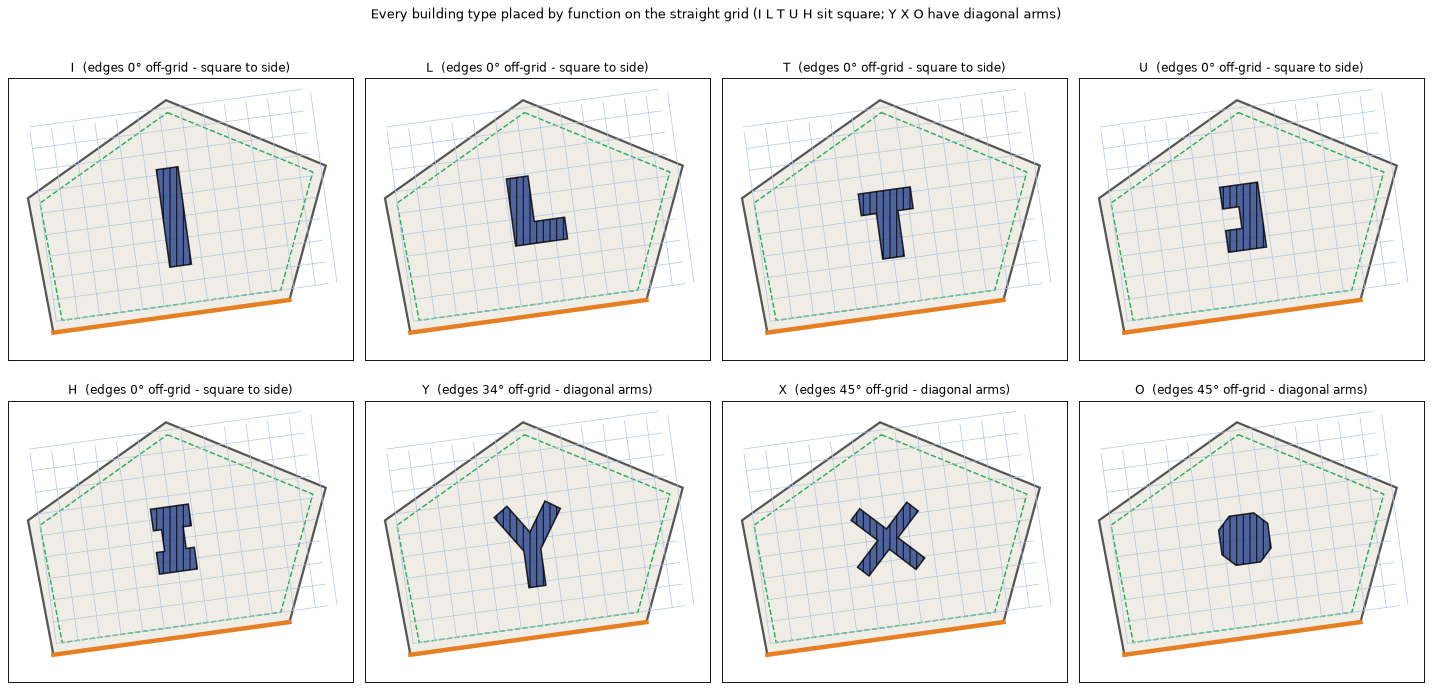

In [4]:
# Every library shape placed by function (here residential -> long side perpendicular)
# on the STRAIGHT grid. Rectilinear shapes sit perfectly square (0 deg off-grid); the
# diagonal-armed Y/X/O keep their arms and align by their dominant axis.
# (Y is a stem + V arms; X is two crossing diagonal bars — the fixed letter shapes.)
ALL_SHAPES = ['I', 'L', 'T', 'U', 'H', 'Y', 'X', 'O']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for s, ax in zip(ALL_SHAPES, axes.ravel()):
    base = [[x, y, 0.0] for x, y in build_shape_model(
        area=650.0, building_type=s, building_depth=12.0, shape_ratio=0.6).polygon.exterior.coords]
    placed, nd = place_by_function_inside(base, grid, 'residential')
    draw_site(ax); draw_grid(ax, grid, nodes=False)
    if placed:
        draw_building(ax, placed)
        off = max_edge_off_grid(placed, grid)
        tag = 'square to side' if off < 1 else 'diagonal arms'
        ax.set_title(f'{s}  (edges {off:.0f}° off-grid - {tag})', fontsize=11)
    else:
        ax.set_title(f'{s}  (no in-site fit)', fontsize=11)
    ax.set_xlim(-25, 165); ax.set_ylim(-15, 140); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Every building type placed by function on the straight grid (I L T U H sit square; Y X O have diagonal arms)', y=1.0)
plt.tight_layout(); plt.show()

## 2. Free placement vs. grid-aligned placement

The same building, the same site. Left: the old free sweep (any of 36 rotations, anywhere). Right:
restricted to grid nodes × {parallel, perpendicular}. The right reads as *intentional* — every
candidate is parallel to the chosen frontage.

free candidates    : 4008  (mixed rotations)
aligned candidates : 98  (all parallel/perpendicular to the chosen side)


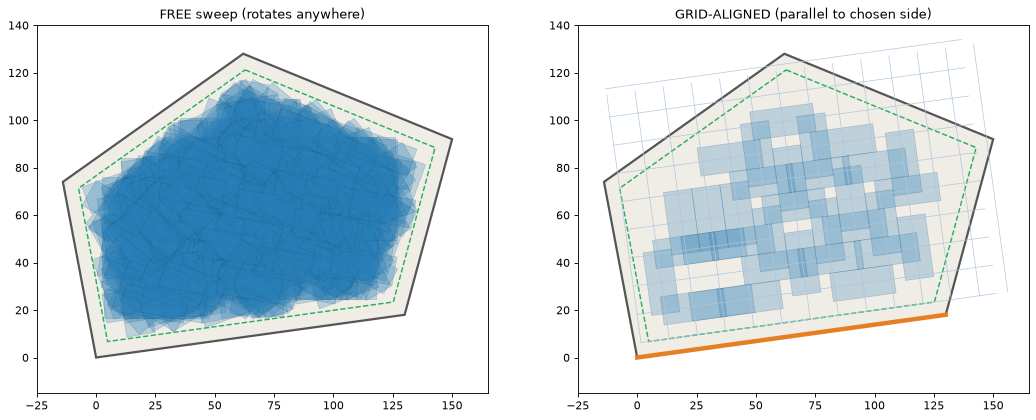

In [5]:
def base_boundary(btype, area, depth=12.0, ratio=0.5):
    poly = build_shape_model(area=area, building_type=btype, building_depth=depth, shape_ratio=ratio).polygon
    return [[round(float(x), 3), round(float(y), 3), 0.0] for x, y in poly.exterior.coords]

bldg = base_boundary('I', 320.0)
SET = {'default_setback': 6.0}

free = sample_valid_placements(bldg, SITE, rotation_step_degrees=10, grid_step=8.0, site_setbacks=SET)
aligned = sample_valid_placements(bldg, SITE, grid=grid, site_setbacks=SET)
print(f'free candidates    : {len(free)}  (mixed rotations)')
print(f'aligned candidates : {len(aligned)}  (all parallel/perpendicular to the chosen side)')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cands, title, show_grid in ((axes[0], free[::7], 'FREE sweep (rotates anywhere)', False),
                                     (axes[1], aligned[::3], 'GRID-ALIGNED (parallel to chosen side)', True)):
    draw_site(ax)
    if show_grid: draw_grid(ax, grid, nodes=False)
    for c in cands:
        ax.add_patch(plt.Polygon([(p[0], p[1]) for p in c['boundary'][:-1]],
                                 fc='#2980b9', ec='#1b4f72', lw=0.6, alpha=0.25))
    ax.set_title(title); ax.set_xlim(-25, 165); ax.set_ylim(-15, 140)
plt.show()

## 4. Use-driven placement — commercial hugs the frontage

Same building, same grid, different `use`. **Commercial / office / retail** buildings pick up a
`boundary_proximity` objective and line the chosen frontage; **residential** leans on view + sun and
sits back. The optimizer is exhaustive over the (small) aligned candidate set, so the best option
is exact.

 commercial: objectives=['unblocked_view', 'boundary_proximity']
             best distance to chosen frontage =  11.00 m   (combined 0.792)
residential: objectives=['unblocked_view']
             best distance to chosen frontage =  17.14 m   (combined 1.000)


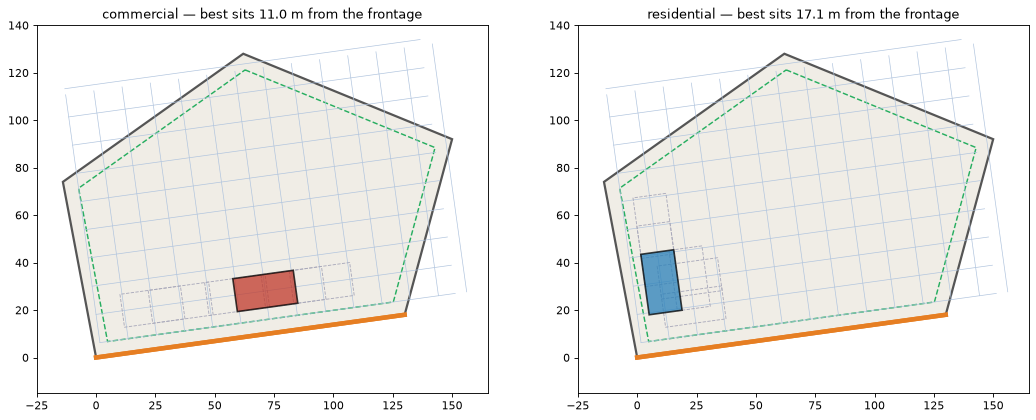

In [6]:
from agent.tools.view_analysis import _coerce_polygon_2d
site_poly = _coerce_polygon_2d(SITE)
side_i = grid['alignment_side_index']
coords = [(p[0], p[1]) for p in SITE[:-1]]
ref_line = [list(coords[side_i]), list(coords[(side_i + 1) % len(coords)])]   # the chosen side segment

shop = base_boundary('I', 360.0, depth=14.0)
results = {}
for use in ('commercial', 'residential'):
    res = optimize_aligned_placement(
        base_boundary=shop, site_boundary=SITE, grid=grid, use=use,
        reference_line=ref_line, site_setbacks=SET, saved_option_count=6,
    )
    best = res['options'][0]
    dist = ref_line_dist = _coerce_polygon_2d(best['boundary']).distance(
        __import__('shapely').geometry.LineString(ref_line))
    results[use] = (res, best, dist)
    print(f"{use:>11}: objectives={[c['name'] for c in res['objective_configs']]}")
    print(f"{'':>11}  best distance to chosen frontage = {dist:6.2f} m   (combined {best['combined_score']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, use in zip(axes, ('commercial', 'residential')):
    res, best, dist = results[use]
    draw_site(ax); draw_grid(ax, grid, nodes=False)
    ax.plot([ref_line[0][0], ref_line[1][0]], [ref_line[0][1], ref_line[1][1]], color='#e67e22', lw=4, zorder=4)
    for opt in res['options'][1:]:
        ax.add_patch(plt.Polygon([(p[0], p[1]) for p in opt['boundary'][:-1]], fc='none', ec='#aab', lw=0.8, ls='--', zorder=4))
    c = '#c0392b' if use == 'commercial' else '#2980b9'
    ax.add_patch(plt.Polygon([(p[0], p[1]) for p in best['boundary'][:-1]], fc=c, ec='k', lw=1.5, alpha=0.75, zorder=6))
    ax.set_title(f'{use} — best sits {dist:.1f} m from the frontage')
    ax.set_xlim(-25, 165); ax.set_ylim(-15, 140)
plt.show()

## Summary

- `site_grid.derive_site_grid` builds a **straight grid** from a **chosen side** (the longest side by
  default; in practice the side chosen by sun analysis): lines exactly **parallel and perpendicular**
  to that side — no warping. `aligned_orientations` is the only orientation set a building may take.
- **Placement is rigid and grid-aligned, oriented by FUNCTION.** `orientation_for_function` /
  `place_building_by_function` rotate a footprint to one of the two grid-aligned orientations based on
  its use: **commercial/retail → long side parallel** to the chosen side (frontage);
  **residential/office → long side perpendicular** (deeper, light + privacy). Edit `FUNCTION_FRONTAGE`
  to tune the rule. Rectilinear shapes (I L T U H) sit perfectly square; diagonal-armed Y/X/O keep
  their arms and align by their dominant axis. The agent asks the user the function and passes
  `function=`.
- `optimize_aligned_placement` exhaustively ranks grid-node × aligned-orientation candidates with a
  **use-driven** objective mix (commercial → `boundary_proximity`, residential → view + sun), and
  `place_buildings_aligned` sequences several buildings, each aligned and clearing the rest.

Backend: `agent/tools/site_grid.py` (straight grid + `orientation_for_function` /
`place_building_by_function` + `grid_alignment`/`boundary_proximity` objectives and
`optimize_aligned_placement`/`place_buildings_aligned`/grid-aware `sample_valid_placements` in
`view_optimizer.py`). Regressions: `benchmarking/test_site_grid.py` (41 tests). Frontend overlay:
`frontend/site/GridOverlay.tsx` via `POST /tools/{site_grid,aligned_placement}`.

placed: 2
  building 0 ( commercial): align=1.000  view=1.00  combined=0.790
  building 1 (residential): align=1.000  view=1.00  combined=0.907


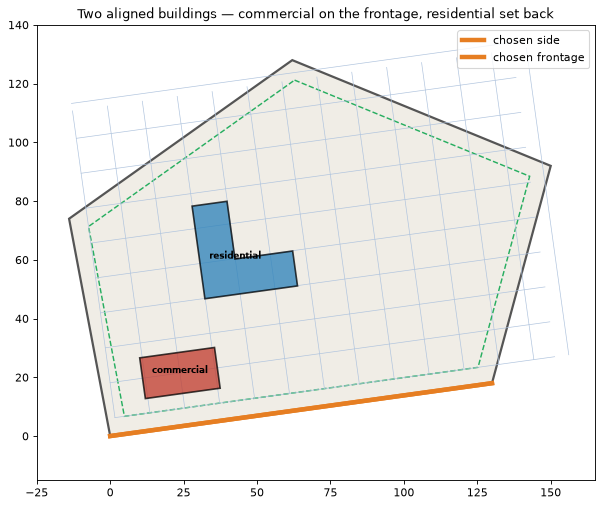

In [7]:
from agent.tools.sun_analysis import compute_sun_vectors
sun_vectors = compute_sun_vectors()   # worst-case western sun

layout = place_buildings_aligned(
    [{'base_boundary': base_boundary('I', 360.0, depth=14.0), 'use': 'commercial'},
     {'base_boundary': base_boundary('L', 620.0, depth=12.0), 'use': 'residential'}],
    SITE, grid, site_setbacks=SET, reference_line=ref_line,
    sun_vectors=sun_vectors, sun_weight=0.5, min_separation=6.0,
)
print('placed:', layout['placed_count'])
for b in layout['buildings']:
    print(f"  building {b['building_index']} ({b['use']:>11}): align={b['alignment_score']:.3f}  "
          f"view={b['unblocked_view_score']:.2f}  combined={b['combined_score']:.3f}")

fig, ax = plt.subplots(figsize=(9, 8))
draw_site(ax); draw_grid(ax, grid, nodes=False)
ax.plot([ref_line[0][0], ref_line[1][0]], [ref_line[0][1], ref_line[1][1]], color='#e67e22', lw=4, zorder=4, label='chosen frontage')
for b, c in zip(layout['buildings'], ('#c0392b', '#2980b9')):
    ax.add_patch(plt.Polygon([(p[0], p[1]) for p in b['boundary'][:-1]], fc=c, ec='k', lw=1.5, alpha=0.75, zorder=6))
    cen = b['centroid_xy']; ax.text(cen[0], cen[1], b['use'], ha='center', fontsize=8, weight='bold', zorder=7)
ax.legend(loc='upper right'); ax.set_title('Two aligned buildings \u2014 commercial on the frontage, residential set back')
ax.set_xlim(-25, 165); ax.set_ylim(-15, 140)
plt.show()